In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA

In [2]:
in_dir = "simulations/variable-delay"
data = np.loadtxt(os.path.join(in_dir, "data.txt"))
weights = np.loadtxt(os.path.join(in_dir, "weights.txt"))
components = np.loadtxt(os.path.join(in_dir, "components.txt"))
n_signals = components.shape[0]

In [3]:
ica = FastICA(n_components=n_signals, whiten="unit-variance")
ica_components = ica.fit_transform(data)  # Reconstruct signals
ica_weights = ica.mixing_  # Get estimated mixing matrix

In [4]:
corrs = np.corrcoef(np.vstack((components, ica_components.T)))
corrs = corrs[:n_signals, n_signals:]
print(np.round(corrs, 3))

[[-0.017 -0.004 -0.131]
 [ 0.006  0.665 -0.594]
 [ 0.089  0.015  0.028]]


In [5]:
corrs = np.corrcoef(np.hstack((weights, ica_weights)).T)
corrs = corrs[:n_signals, n_signals:]
print(np.round(corrs, 3))

[[ 0.029 -0.031 -0.028]
 [ 0.007  0.268 -0.21 ]
 [ 0.025  0.013 -0.048]]


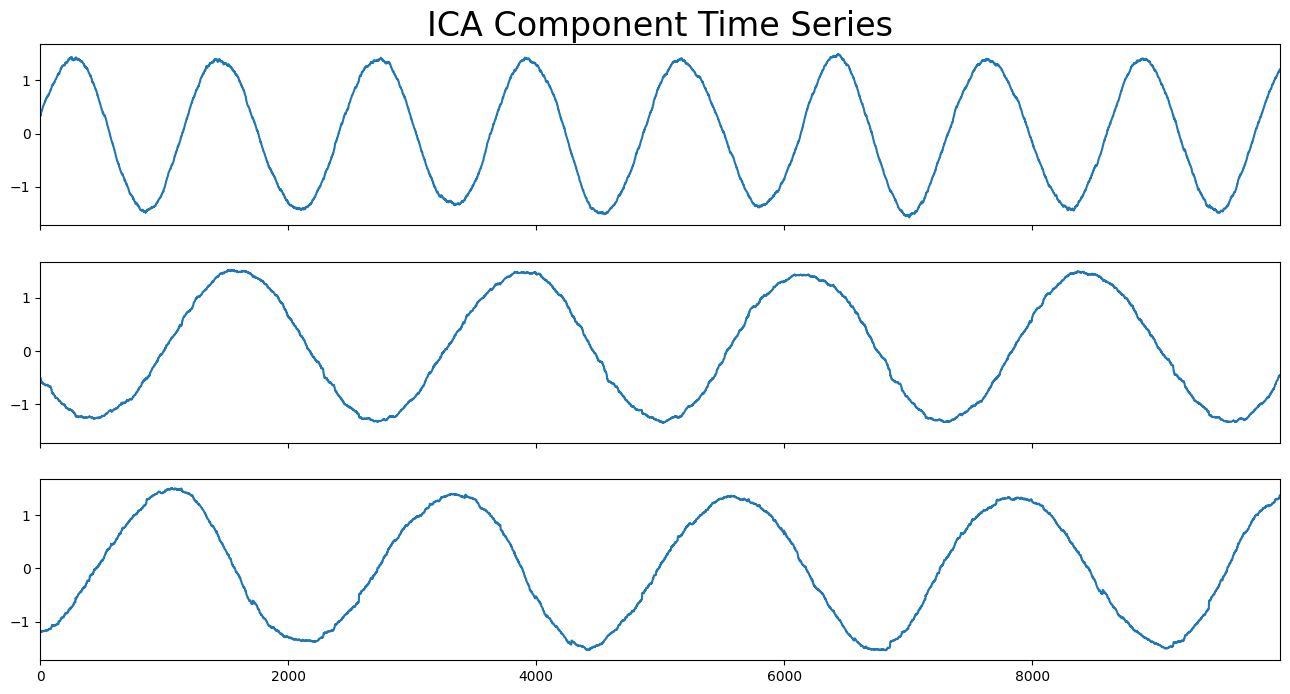

In [6]:
n_volumes, n_signals = ica_components.shape

fig, axes = plt.subplots(figsize=(16, 8), nrows=3, sharex=True, sharey=True)
axes[0].set_title("ICA Component Time Series", fontsize=24)
for i_signal in range(n_signals):
    axes[i_signal].plot(ica_components[:, i_signal])

axes[0].set_xlim(0, n_volumes - 1)
fig.savefig(os.path.join(in_dir, "ica_components.png"))